In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA

### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
# save x and y variables from df
X = df[["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
      "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"]]
y = df["Heating Load"]

# split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# initiate scaler
scaler = StandardScaler().fit(X_train)

# scale X train and X test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [38]:
# initiate model
ols = LinearRegression()

ols.fit(X_train_scaled, y_train)

# predict y variable
y_pred = ols.predict(X_test_scaled)

# calculate MSE
mse_ols = mean_squared_error(y_test, y_pred)

In [40]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [15]:
# assign lambda values to loop over
lambdas = np.logspace(-4,4, 100)

# initiate model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

# fit to training data
ridge_cv.fit(X_train_scaled, y_train)

# explore best lambda
print(f'The best lambda value for this model is {ridge_cv.alpha_}.')

The best lambda value for this model is 0.20565123083486536.


In [16]:
# create dictionary with values for table
table = {
    # feature names
    'Feature': ["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
      "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"],
    
    # OLS coefficients
    'OLS Coefficient': ols.coef_,
    
    # ridge coefficients
    'Ridge Coefficient': ridge_cv.coef_
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

                     Feature  OLS Coefficient  Ridge Coefficient
0       Relative Compactness    -6.421598e+01          -6.352418
1               Surface Area     1.162672e+12          -3.474392
2                  Wall Area    -1.162672e+12           0.816587
3                  Roof Area    -2.325344e+12          -3.797180
4             Overall Height     4.125416e+00           7.306373
5                Orientation    -2.387778e-02          -0.025299
6               Glazing Area     1.993059e+01           2.670852
7  Glazing Area Distribution     2.300219e-01           0.356417


In [17]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [32]:
# predict using the test set
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# compute MSE
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

In [33]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

In [21]:
# initialize empty data frame
ridge_plot = pd.DataFrame()

for x in lambdas:
    
    # create array of lambda values
    lambda_array = np.array([x, x, x, x, x, x, x, x])
    
    # fit model
    ridge = Ridge(alpha=x)
    ridge.fit(X_train_scaled, y_train)
    
    # assemble data frame with lambda values, feature, and coefficients as columns
    d = {"Lambda": lambda_array, 
         "Feature":["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
      "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"], 
         "Coefficients": ridge.coef_}
    coef_df = pd.DataFrame(data=d)
    
    # concat on the end of the complete dataframe
    ridge_plot = pd.concat([ridge_plot, coef_df])

Text(0.5, 1.0, 'Ridge Regression Coefficient Profiles')

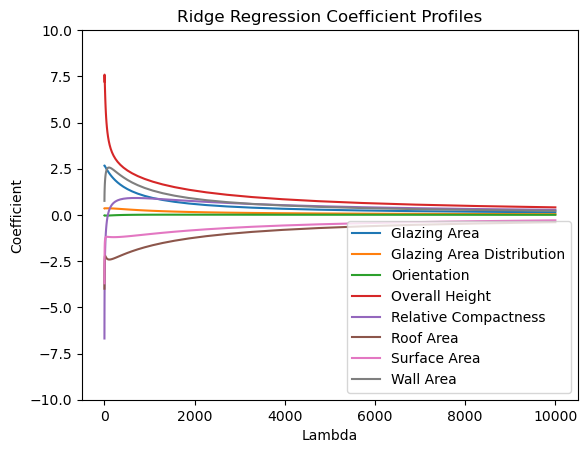

In [31]:
# plot a line for each feature
for feature, group in ridge_plot.groupby("Feature"):
    plt.plot(group["Lambda"], group["Coefficients"], label=feature)
    

plt.ylim([-10, 10])
plt.legend()
plt.xlabel("Lambda")
plt.ylabel("Coefficient")
plt.title("Ridge Regression Coefficient Profiles")

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Based on the profile above, it appears that glazing area and roof area are the two most important predictors. They appear to have the largest coefficients for the longest time, whereas other features' coefficients approach 0.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [42]:
# initialize model
lasso_cv = LassoCV(alphas=lambdas, cv=10)

# fit to training data
lasso_cv.fit(X_train_scaled, y_train)

# explore best lambda
print(f'The best lambda value for this model is {lasso_cv.alpha_}.')

The best lambda value for this model is 0.0016297508346206433.


In [43]:
# create dictionary with values for table
table = {
    # feature names
    'Feature': ["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
      "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"],
    
    # OLS coefficients
    'OLS Coefficient': ols.coef_,
    
    # ridge coefficients
    'Lasso Coefficient': lasso_cv.coef_
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

                     Feature  OLS Coefficient  Ridge Coefficient
0       Relative Compactness        -6.686924          -6.418330
1               Surface Area        -3.701472          -6.231035
2                  Wall Area         0.761142           2.152524
3                  Roof Area        -3.992429          -1.044324
4             Overall Height         7.216818           7.309160
5                Orientation        -0.026067          -0.023593
6               Glazing Area         2.670032           2.670194
7  Glazing Area Distribution         0.356042           0.354971


In [44]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [45]:
# predict y values from model
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# compute MSE
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

In [46]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [49]:
# create dictionary with values for table
table = {
    # feature names
    'Feature': ["Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
      "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"],
    
    # OLS coefficients
    'OLS Coefficient': ols.coef_,
    
    # ridge coefficients
    'Ridge Coefficient': ridge_cv.coef_,
    
    # lasso coefficients
    'Lasso Coefficient': lasso_cv.coef_
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

                  Feature  OLS Coefficient  Ridge Coefficient  Lasso Coefficient
     Relative Compactness        -6.686924          -6.352418          -6.418330
             Surface Area        -3.701472          -3.474392          -6.231035
                Wall Area         0.761142           0.816587           2.152524
                Roof Area        -3.992429          -3.797180          -1.044324
           Overall Height         7.216818           7.306373           7.309160
              Orientation        -0.026067          -0.025299          -0.023593
             Glazing Area         2.670032           2.670852           2.670194
Glazing Area Distribution         0.356042           0.356417           0.354971


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.277e+00, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(


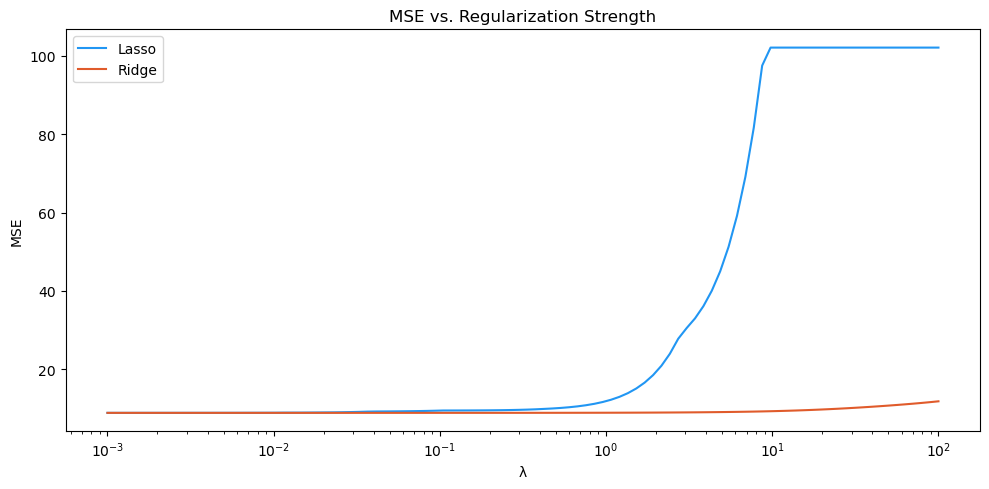

In [52]:
# Visualize lambdas against MSE for Lasso and Ridge
mse_lasso = []
mse_ridge = []

lambdas = np.logspace(-3, 2, 100) # 100 values from 0.001 to 100

for lam in lambdas:
    lasso = Lasso(alpha = lam)
    ridge = Ridge(alpha = lam)

    # fit for each model
    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))


plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='#2196F3')
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
for lam in lambdas:
    if lam == 0:
        ols = LinearRegression().fit(X_train, y_train)
        data.append(pd.DataFrame({
            'Ridge': ols.coef_,
            'Lasso': ols.coef_
        }, index=['X1', 'X2', 'X1_corr', 'X2_corr', 'Noise1', 'Noise2']))
    else:
        ridge = Ridge(alpha=lam).fit(X_train, y_train)
        lasso = Lasso(alpha=lam).fit(X_train, y_train)
        data.append(pd.DataFrame({
            'Ridge': ridge.coef_,
            'Lasso': lasso.coef_
        }, index=['X1', 'X2', 'X1_corr', 'X2_corr', 'Noise1', 'Noise2']))

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()
for i, df in enumerate(data):
    df.plot.bar(ax=axes[i], width=0.8)
    title = 'λ = 0 (OLS)' if lambdas[i] == 0 else f'λ = {lambdas[i]}'
    axes[i].set_title(title)
    axes[i].set_xticklabels(df.index, rotation=45)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ymin = min(df.values.min(), 0)
    ymax = max(df.values.max(), 0)
    pad = max((ymax - ymin) * 0.15, 0.5)
    axes[i].set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.218e+02, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(


NameError: name 'data' is not defined

> **Q4: Which model would you pick for this dataset? Why?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [ ]:
pca_full = ...

explained_var = ...
cumulative_var = ...

explained_var

In [ ]:
grader.check("q7")

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [ ]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = ...

pca_final = ...
X_train_pca = ...
X_test_pca  = ...

ols_pcr = ...

y_pred_pcr = ...
mse_pcr = ...



<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [ ]:
grader.check_all()